<a href="https://colab.research.google.com/github/s-ahmedabozaid-byte/CampusHub/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import kagglehub

DATA_DIR = kagglehub.dataset_download("andrewmvd/medical-mnist")
print("DATA_DIR:", DATA_DIR)

Using Colab cache for faster access to the 'medical-mnist' dataset.
DATA_DIR: /kaggle/input/medical-mnist


In [9]:
import os

image_paths = []

for root, _, files in os.walk(DATA_DIR):
    for f in files:
        if f.lower().endswith((".png",".jpg",".jpeg")):
            image_paths.append(os.path.join(root, f))

print("Total images:", len(image_paths))

Total images: 58954


In [13]:
import random

random.shuffle(image_paths)

train_size = int(0.8 * len(image_paths))
train_paths = image_paths[:train_size]
test_paths = image_paths[train_size:]

print("Train:", len(train_paths))
print("Test:", len(test_paths))

Train: 3524
Test: 882


tf.data **Pipeline**

In [14]:
import tensorflow as tf

IMG_SIZE = 64
BATCH_SIZE = 32

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

def process(path):
    x = load_image(path)
    return x, x

train_ds = tf.data.Dataset.from_tensor_slices(train_paths)
train_ds = train_ds.shuffle(1000).map(process).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices(test_paths)
test_ds = test_ds.map(process).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

**Autoencoder**

In [15]:
from tensorflow.keras import layers, Model

def build_ae():
    inp = layers.Input((64,64,1))

    x = layers.Conv2D(32,3,2,'same',activation='relu')(inp)
    x = layers.Conv2D(64,3,2,'same',activation='relu')(x)
    x = layers.Flatten()(x)
    z = layers.Dense(64)(x)

    x = layers.Dense(16*16*64, activation='relu')(z)
    x = layers.Reshape((16,16,64))(x)
    x = layers.Conv2DTranspose(64,3,2,'same',activation='relu')(x)
    x = layers.Conv2DTranspose(32,3,2,'same',activation='relu')(x)
    out = layers.Conv2D(1,3,padding='same',activation='sigmoid')(x)

    return Model(inp, out)

ae = build_ae()
ae.compile(optimizer='adam', loss='mse')

history_ae = ae.fit(train_ds, validation_data=test_ds, epochs=5)

Epoch 1/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 79s 667ms/step - loss: 0.0087 - val_loss: 0.0078
Epoch 2/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 20s 178ms/step - loss: 0.0059 - val_loss: 0.0048
Epoch 3/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - loss: 0.0042 - val_loss: 0.0038
Epoch 4/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 0.0033 - val_loss: 0.0030
Epoch 5/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - loss: 0.0027 - val_loss: 0.0025


**VAE**

In [16]:
class VAE(tf.keras.Model):
    def __init__(self):
        super().__init__()

        self.encoder = tf.keras.Sequential([
            layers.InputLayer((64,64,1)),
            layers.Conv2D(32,3,2,'same',activation='relu'),
            layers.Conv2D(64,3,2,'same',activation='relu'),
            layers.Flatten(),
            layers.Dense(64)
        ])

        self.z_mean = layers.Dense(64)
        self.z_log_var = layers.Dense(64)

        self.decoder = tf.keras.Sequential([
            layers.InputLayer((64,)),
            layers.Dense(16*16*64, activation='relu'),
            layers.Reshape((16,16,64)),
            layers.Conv2DTranspose(64,3,2,'same',activation='relu'),
            layers.Conv2DTranspose(32,3,2,'same',activation='relu'),
            layers.Conv2D(1,3,padding='same',activation='sigmoid')
        ])

    def sample(self, m, v):
        eps = tf.random.normal(tf.shape(m))
        return m + tf.exp(0.5*v)*eps

    def call(self, x):
        h = self.encoder(x)
        m = self.z_mean(h)
        v = self.z_log_var(h)
        z = self.sample(m, v)

        out = self.decoder(z)

        recon = tf.reduce_mean(tf.keras.losses.mse(x, out))
        kl = -0.5 * tf.reduce_mean(1 + v - tf.square(m) - tf.exp(v))
        self.add_loss(recon + kl)

        return out

vae = VAE()
vae.compile(optimizer='adam')

history_vae = vae.fit(train_ds, validation_data=test_ds, epochs=5)

Epoch 1/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 22s 149ms/step - loss: 0.0100 - val_loss: 0.0085
Epoch 2/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - loss: 0.0083 - val_loss: 0.0084
Epoch 3/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - loss: 0.0082 - val_loss: 0.0083
Epoch 4/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - loss: 0.0081 - val_loss: 0.0083
Epoch 5/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - loss: 0.0081 - val_loss: 0.0082


Loss **Curve**

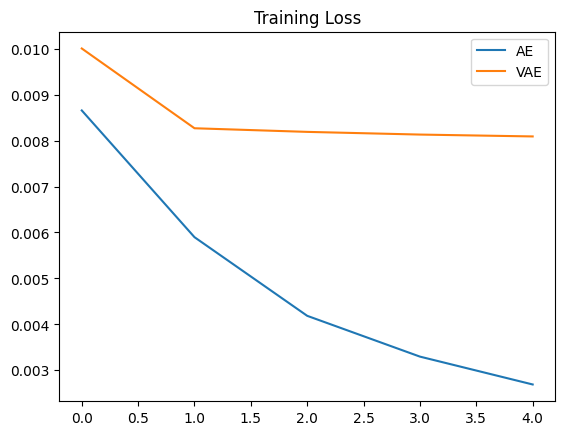

In [17]:
import matplotlib.pyplot as plt

plt.plot(history_ae.history['loss'], label='AE')
plt.plot(history_vae.history['loss'], label='VAE')
plt.legend()
plt.title("Training Loss")
plt.show()

**Reconstruction**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step


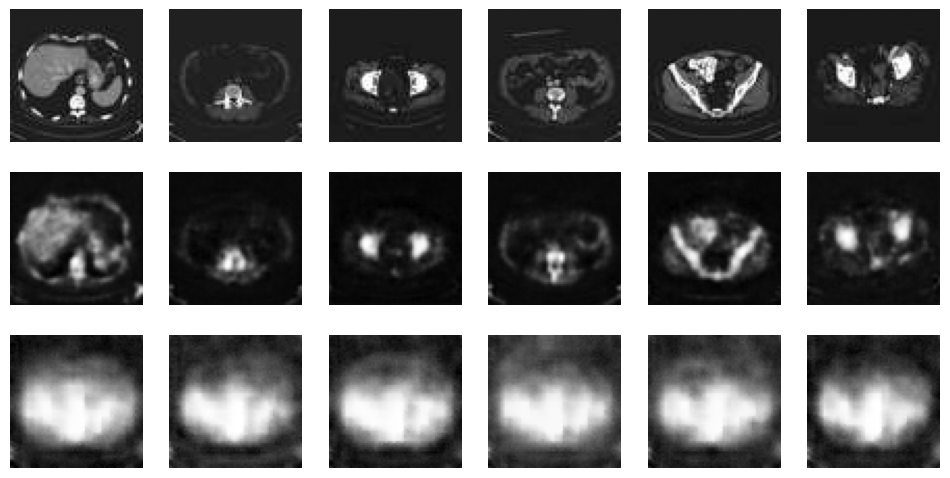

In [18]:
for x,_ in test_ds.take(1):
    break

ae_out = ae.predict(x)
vae_out = vae.predict(x)

n = 6
plt.figure(figsize=(12,6))

for i in range(n):
    plt.subplot(3,n,i+1); plt.imshow(x[i].numpy().squeeze(), cmap='gray'); plt.axis('off')
    plt.subplot(3,n,i+n+1); plt.imshow(ae_out[i].squeeze(), cmap='gray'); plt.axis('off')
    plt.subplot(3,n,i+2*n+1); plt.imshow(vae_out[i].squeeze(), cmap='gray'); plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


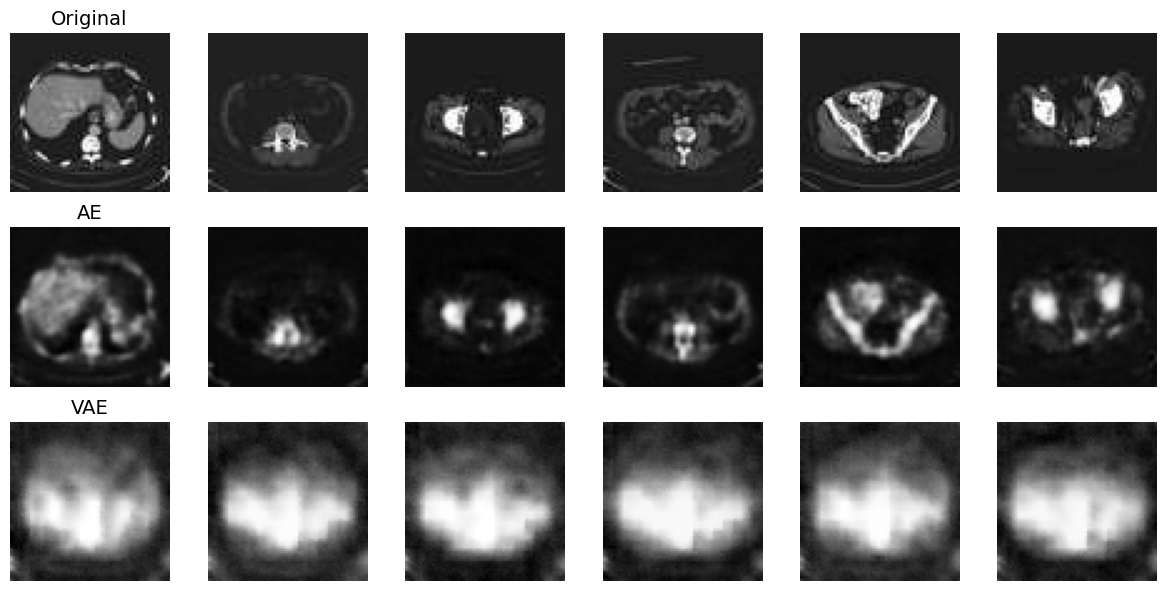

In [23]:
for x,_ in test_ds.take(1):
    break

ae_out = ae.predict(x)
vae_out = vae.predict(x)

n = 6
plt.figure(figsize=(12,6))

for i in range(n):
    # (Original)
    plt.subplot(3,n,i+1)
    plt.imshow(x[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title("Original", fontsize=14)

    # (AE)
    plt.subplot(3,n,i+n+1)
    plt.imshow(ae_out[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title("AE", fontsize=14)

    # (VAE)
    plt.subplot(3,n,i+2*n+1)
    plt.imshow(vae_out[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title("VAE", fontsize=14)

plt.tight_layout()
plt.show()

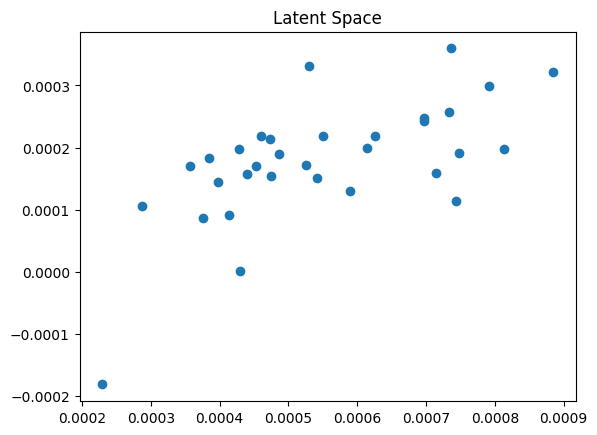

In [19]:
#Latent Space Visualization
z = vae.encoder(x)
z = vae.z_mean(z).numpy()

plt.scatter(z[:,0], z[:,1])
plt.title("Latent Space")
plt.show()

Latent **Walk**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


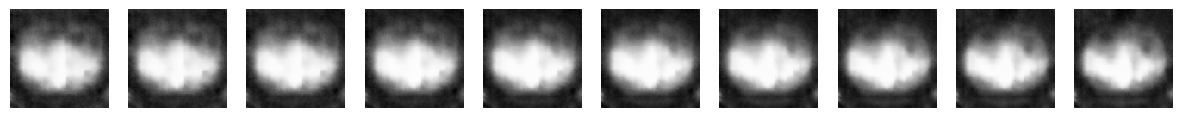

In [20]:
import numpy as np

z1 = np.random.normal(size=(1,64))
z2 = np.random.normal(size=(1,64))

imgs = []
for t in np.linspace(0,1,10):
    z = (1-t)*z1 + t*z2
    imgs.append(vae.decoder.predict(z)[0])

plt.figure(figsize=(15,2))
for i,img in enumerate(imgs):
    plt.subplot(1,10,i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.axis('off')
plt.show()

Generated **Samples**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step


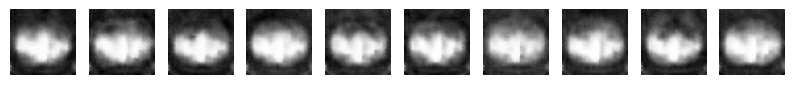

In [21]:
z = np.random.normal(size=(10,64))
gen = vae.decoder.predict(z)

plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(gen[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()

**Denoising**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


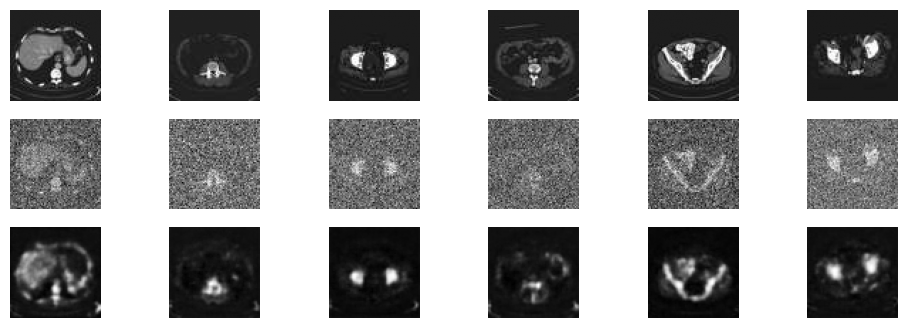

In [22]:
noise = tf.random.normal(tf.shape(x)) * 0.2
noisy = x + noise

denoised = ae.predict(noisy)

plt.figure(figsize=(12,4))
for i in range(6):
    plt.subplot(3,6,i+1); plt.imshow(x[i].numpy().squeeze(), cmap='gray'); plt.axis('off')
    plt.subplot(3,6,i+7); plt.imshow(noisy[i].numpy().squeeze(), cmap='gray'); plt.axis('off')
    plt.subplot(3,6,i+13); plt.imshow(denoised[i].squeeze(), cmap='gray'); plt.axis('off')

plt.show()